<div style="background-color: #ffffff; color: #000000; padding: 10px;">
<div style="display: flex; justify-content: space-between; align-items: center; background-color: #ffffff; color: #000000; padding: 10px;">
    <img src="../00_aisc/img/logo_aisc_150dpi.png" height="80" style="margin-right: auto;" alt="Logo of the AI Service Center Berlin-Brandenburg.">
    <img src="../00_aisc/img/logo_bmftr_de.png" height="150" style="margin-left: auto;" alt="Logo of the German Federal Ministry of Research, Technology and Space: Gefördert vom Bundesministerium für Forschung, Technologie und Raumfahrt.">
</div>
<h1> RAG III 
</div>

# 02 — Document Ingestion

Dieses Notebook führt die komplette Ingestion-Pipeline für Workshop 3 durch:

1. PDF-Dokument mit Docling in Markdown konvertieren
2. Markdown-Text normalisieren und in Chunks aufteilen
3. Chunks mit dem Embedding-Modell vektorisieren
4. Vektoren in die Qdrant-Datenbank hochladen

Es führt also im Wesentlichen die Schritte aus, die in Workshop 2 besprochen wurden.

> **Einmalig ausführen** vor den Notebooks 03–04. Die Qdrant-Collection bleibt
> zwischen Notebook-Sessions erhalten (persistenter Docker-Storage).

**Voraussetzung:** `00_setup.ipynb` muss erfolgreich durchgelaufen sein.

In [1]:
# Gemeinsame Konfiguration laden (Pfade, Modellnamen, Qdrant-Einstellungen)
from config import *

# --- Imports ---
import json
import re
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from litellm import embedding
from docling.document_converter import DocumentConverter
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

=== Workshop-Konfiguration ===
  PDF:             IT_Grundschutz_Kompendium_Edition2023.pdf | exists: True
  Datensatz:       40_einfach (GSKI_Fragen-Antworten-Fundstellen_40_Einfach.csv, sep=",") | exists: True
  Embedding:       openai/octen-embedding-8b (max_chars=None)
  RAG-Modell:      openai/gpt-oss-120b
  Evaluator:       gpt-oss-120b
  API Base URL:    https://api.aisc.hpi.de/
  API Key gesetzt: True
  Qdrant:          localhost:6333
  Chunking-Modus:  json_structured_sections
  Collection:      grundschutz_chunks_json_structured_sections__octen-embedding-8b
  Chunking:        MAX_CHUNK=1200, OVERLAP=200, TOP_K=5


## 1) Docling-Konvertierung: PDF → Markdown + JSON

Wir verwenden [Docling](https://github.com/DS4SD/docling) zur strukturierten Textextraktion
aus dem IT-Grundschutz-Kompendium (PDF). Docling liefert zwei Exportformate:

- **Markdown** — Text mit erhaltenen Überschriften (`##`), gut für überschriftenbasiertes Chunking
- **JSON** — Strukturierte Elemente mit Labels (`section_header`, `body_text`, ...) und Seitenzahlen

> **Laufzeit:** Die Konvertierung dauert ca. 4 Minuten. Mit `LOAD_FROM_CACHE = True`
> werden gespeicherte Ergebnisse geladen (< 1 Sekunde).

In [2]:
# --- Toggle: auf True setzen, um gespeicherte Docling-Ergebnisse zu laden ---
LOAD_FROM_CACHE = True
MARKDOWN_CACHE = DATA_DIR / f'{PDF_PATH.stem}.md'
JSON_CACHE = DATA_DIR / f'{PDF_PATH.stem}.json'

if LOAD_FROM_CACHE and MARKDOWN_CACHE.exists() and JSON_CACHE.exists():
    # Gespeicherte Ergebnisse laden (spart ~4 Min Konvertierungszeit)
    markdown_text = MARKDOWN_CACHE.read_text(encoding='utf-8')
    with open(JSON_CACHE, 'r', encoding='utf-8') as f:
        doc_json = json.load(f)
    print(f'Aus Cache geladen: {MARKDOWN_CACHE.name} + {JSON_CACHE.name}')
else:
    # Docling-Konvertierung durchführen
    converter = DocumentConverter()
    result = converter.convert(str(PDF_PATH))
    doc = result.document

    markdown_text = doc.export_to_markdown()       # Markdown-Export mit Überschriften
    doc_json = doc.export_to_dict()                # JSON-Export mit Struktur + Seitenzahlen

    # Ergebnisse für zukünftige Läufe speichern
    MARKDOWN_CACHE.write_text(markdown_text, encoding='utf-8')
    with open(JSON_CACHE, 'w', encoding='utf-8') as f:
        json.dump(doc_json, f, ensure_ascii=False, indent=2)
    print(f'Docling-Konvertierung abgeschlossen und gespeichert.')

print(f'Markdown: {len(markdown_text):,} Zeichen')
print(f'JSON: {len(doc_json.get("texts", []))} Textelemente')

Aus Cache geladen: IT_Grundschutz_Kompendium_Edition2023.md + IT_Grundschutz_Kompendium_Edition2023.json
Markdown: 2,470,835 Zeichen
JSON: 15864 Textelemente


## 2) Text-Normalisierung und Chunking

Docling kann OCR-Artefakte bei deutschen Umlauten erzeugen (z.B. `/C231` statt `ü`).
Die Funktion `normalize_text()` bereinigt diese im Markdown, `normalize_json()` im JSON.

**Zwei Chunking-Methoden:**

1. **`markdown_headers`** — Markdown-Export entlang von Überschriften splitten, mit `MAX_CHUNK` und `OVERLAP`
2. **`json_structured_sections`** — JSON-Export entlang von Heading-Labels splitten, ohne Größenlimit

Beide Methoden geben Records im gleichen Format zurück: `{chunk_id, text, metadata}`

In [3]:
# ---------------------------------------------------------------------------
# Hilfsfunktionen: Normalisierung + absatzbasiertes Splitting
# (werden von beiden Chunking-Methoden intern verwendet)
# ---------------------------------------------------------------------------

# Mapping von Docling-OCR-Platzhaltern auf echte deutsche Sonderzeichen.
# Docling erzeugt je nach Font/Encoding im PDF unterschiedliche Codes
# für dasselbe Zeichen — daher gibt es mehrere Einträge pro Umlaut.
_UMLAUT_MAP = {
    'C196': 'Ä', 'C214': 'Ö', 'C218': 'Ö', 'C220': 'Ü',
    'C216': 'Ä', 'C219': 'Ü', 'C228': 'ä', 'C229': 'ä',
    'C230': 'ö', 'C231': 'ü', 'C246': 'ö', 'C252': 'ü', 'C223': 'ß',
}

def _fix_german_umlauts(text: str) -> str:
    """Replace Docling OCR placeholders (e.g. /C231) with actual German umlauts.

    Args:
        text: Raw text possibly containing OCR placeholder codes.

    Returns:
        Text with placeholders replaced by the correct Unicode characters.
    """
    def repl(match: re.Match) -> str:
        code = match.group(1)
        if not code.startswith('C'):
            code = f'C{code}'
        return _UMLAUT_MAP.get(code, match.group(0))
    text = re.sub(r'/?(C\d{3})', repl, text)
    text = re.sub(r'[ \t]{2,}', ' ', text)
    return text


def normalize_text(text: str) -> str:
    """Normalize extracted text by fixing line endings, umlauts, and excess whitespace.

    Args:
        text: Raw text from Docling extraction.

    Returns:
        Cleaned text with consistent line endings and fixed umlauts.
    """
    text = text.replace('\r\n', '\n').replace('\r', '\n')  # Zeilenenden vereinheitlichen
    text = _fix_german_umlauts(text)
    text = re.sub(r'\n{3,}', '\n\n', text)                 # Max. zwei Leerzeilen
    return text.strip()


def normalize_json(doc_json: dict) -> dict:
    """Normalize only content text fields in the Docling JSON, not metadata.

    Args:
        doc_json: Raw Docling JSON dict from export_to_dict().

    Returns:
        JSON dict with umlauts fixed in 'text' and 'orig' fields.
    """
    def walk(obj):
        if isinstance(obj, dict):
            out = {}
            for k, v in obj.items():
                if k in {'text', 'orig'} and isinstance(v, str):  # Nur Textfelder normalisieren
                    out[k] = _fix_german_umlauts(v)
                else:
                    out[k] = walk(v)
            return out
        if isinstance(obj, list):
            return [walk(x) for x in obj]
        return obj
    return walk(doc_json)


def parser_aware_split(text: str, max_chunk: int = 1200, overlap: int = 200) -> List[str]:
    """Split text into overlapping chunks along paragraph boundaries.

    Helper for chunk_markdown_by_headers() to further split oversized sections.

    Args:
        text: Normalized text to split.
        max_chunk: Maximum number of characters per chunk.
        overlap: Number of characters to overlap between consecutive chunks.

    Returns:
        List of text chunks with overlap applied.
    """
    text = normalize_text(text)
    if not text:
        return []

    blocks = text.split('\n\n')  # Text an Absatzgrenzen aufteilen
    chunks = []
    current = ''

    for block in blocks:
        candidate = (current + '\n\n' + block).strip() if current else block
        if len(candidate) <= max_chunk:
            current = candidate
            continue
        if current:
            chunks.append(current)
        if len(block) <= max_chunk:
            current = block
        else:
            start = 0
            while start < len(block):
                end = min(start + max_chunk, len(block))
                chunks.append(block[start:end])
                if end == len(block):
                    break
                start = end - overlap
            current = ''

    if current:
        chunks.append(current)

    # Overlap zwischen Chunks hinzufügen
    if overlap > 0 and chunks:
        with_overlap = [chunks[0]]
        for i in range(1, len(chunks)):
            prefix = chunks[i - 1][-overlap:]  # Letzte `overlap` Zeichen des vorherigen Chunks
            with_overlap.append((prefix + '\n' + chunks[i]).strip())
        return with_overlap

    return chunks

print('Hilfsfunktionen definiert.')

Hilfsfunktionen definiert.


In [4]:
# ---------------------------------------------------------------------------
# Chunking-Methode 1: markdown_headers
# Splittet den Markdown-Export entlang von Überschriften (##, ###, ...).
# Zu große Sektionen werden mit parser_aware_split nachgeteilt.
# ---------------------------------------------------------------------------

def chunk_markdown_by_headers(markdown_text: str, max_chunk: int = 1200, overlap: int = 200) -> List[str]:
    """Split markdown text into chunks along heading boundaries.

    Args:
        markdown_text: Docling-exported markdown text.
        max_chunk: Maximum number of characters per chunk.
        overlap: Overlap in characters for oversized sections.

    Returns:
        List of text chunks.
    """
    text = normalize_text(markdown_text)
    if not text:
        return []

    parts = re.split(r'(?m)^(#{1,6}\s.+)$', text)  # Überschriften als Split-Punkte

    sections = []
    if parts and parts[0].strip():
        sections.append(parts[0].strip())

    for i in range(1, len(parts), 2):  # step=2: springt von Heading zu Heading
        header = parts[i].strip()
        body = parts[i + 1].strip() if i + 1 < len(parts) else ''
        sections.append(f'{header}\n\n{body}'.strip())

    chunks: List[str] = []
    for sec in sections:
        if len(sec) <= max_chunk:
            chunks.append(sec)
        else:
            chunks.extend(parser_aware_split(sec, max_chunk=max_chunk, overlap=overlap))

    return chunks


def records_from_markdown_header_chunks(markdown_text: str) -> List[Dict[str, Any]]:
    """Chunk markdown by headers and wrap into record format.

    Args:
        markdown_text: Docling-exported markdown text.

    Returns:
        List of record dicts with chunk_id, text, and metadata.
    """
    chunks = chunk_markdown_by_headers(markdown_text, max_chunk=MAX_CHUNK, overlap=OVERLAP)
    return [
        {
            'chunk_id': i,
            'text': chunk_text,
            'metadata': {
                'source_file': PDF_PATH.name,
                'chunking_mode': 'markdown_headers',
                'max_chunk': MAX_CHUNK,
                'overlap': OVERLAP,
                'total_chunks': len(chunks),
                'page_numbers': [],     # Markdown-Export enthält keine Seitenzahlen
                'citation_hint': None,
            },
        }
        for i, chunk_text in enumerate(chunks)
    ]

print('Chunking-Methode 1 (markdown_headers) definiert.')

Chunking-Methode 1 (markdown_headers) definiert.


In [5]:
# ---------------------------------------------------------------------------
# Chunking-Methode 2: json_structured_sections
# ---------------------------------------------------------------------------

def records_from_docling_json_structured_sections(doc_json: dict) -> List[Dict[str, Any]]:
    """Create records by grouping JSON elements from heading to heading.

    Each section (heading + body text) becomes one chunk. Page numbers are
    extracted from the Docling provenance metadata.

    Args:
        doc_json: Normalized Docling JSON dict.

    Returns:
        List of record dicts with chunk_id, text, and metadata.
    """
    elements = doc_json.get('texts', [])
    if not isinstance(elements, list):
        return []

    # Labels, die als neue Abschnittsgrenze dienen
    heading_labels = {'section_header', 'section_heading', 'heading', 'title'}

    def extract_page_numbers(node: dict) -> List[int]:
        """Seitenzahlen aus dem Provenance-Feld eines JSON-Elements extrahieren."""
        pages = []
        prov = node.get('prov', [])  # Provenance-Liste mit Seiteninfos
        if isinstance(prov, list):
            for p in prov:
                if isinstance(p, dict) and isinstance(p.get('page_no'), int):
                    pages.append(p['page_no'])
        return sorted(set(pages))

    def format_citation(pages: List[int]):
        """Seitenzahlen als Zitierhinweis formatieren (z.B. 'S. 42' oder 'S. 42-45')."""
        if not pages:
            return None
        if len(pages) == 1:
            return f'S. {pages[0]}'
        return f'S. {pages[0]}-{pages[-1]}'

    items = []
    current_heading = ''
    current_parts: List[str] = []
    current_pages: List[int] = []

    def flush_section():
        """Aktuelle Sektion als Item speichern und zurücksetzen."""
        nonlocal current_parts, current_pages
        if not current_parts:
            return

        body = normalize_text(' '.join(current_parts))
        if not body:
            current_parts = []
            current_pages = []
            return

        # Heading + Body zusammenfügen
        section_text = f'{current_heading}\n\n{body}'.strip() if current_heading else body
        page_numbers = sorted(set(current_pages))

        items.append({
            'text': section_text,
            'page_numbers': page_numbers,
            'citation_hint': format_citation(page_numbers),
        })

        current_parts = []
        current_pages = []

    for el in elements:
        if not isinstance(el, dict):
            continue

        # Furniture (Header/Footer/Seitennummern) ausschließen
        if el.get('content_layer') == 'furniture':
            continue

        raw_text = el.get('text') or el.get('orig') or ''
        if not isinstance(raw_text, str) or not raw_text.strip():
            continue

        text = normalize_text(raw_text)
        if not text:
            continue

        label = (el.get('label') or '').strip()
        pages = extract_page_numbers(el)

        # Bei einem Heading: aktuelle Sektion abschließen und neue beginnen
        if label in heading_labels or (label == 'page_header' and el.get('content_layer') != 'furniture'):
            flush_section()
            current_heading = text
            current_pages.extend(pages)
            continue

        current_parts.append(text)
        current_pages.extend(pages)

    flush_section()  # Letzte Sektion nicht vergessen

    return [
        {
            'chunk_id': i,
            'text': item['text'],
            'metadata': {
                'source_file': PDF_PATH.name,
                'chunking_mode': 'json_structured_sections',
                'max_chunk': None,           # Kein Größenlimit bei dieser Methode
                'overlap': 0,                # Kein Overlap bei dieser Methode
                'total_chunks': len(items),
                'page_numbers': item['page_numbers'],
                'citation_hint': item['citation_hint'],
            },
        }
        for i, item in enumerate(items)
    ]

print('Chunking-Methode 1 (json_structured_sections) definiert.')

Chunking-Methode 1 (json_structured_sections) definiert.


In [6]:
# Alle Chunking-Methoden ausführen.
# Neue Methode hinzufügen = eine Zeile in diesem Dict ergänzen.
doc_json_clean = normalize_json(doc_json)  # Umlaute im JSON normalisieren

all_records = {
    'markdown_headers': records_from_markdown_header_chunks(markdown_text),
    'json_structured_sections': records_from_docling_json_structured_sections(doc_json_clean),
}

# Statistiken pro Methode ausgeben
for method_name, records in all_records.items():
    lengths = [len(r['text']) for r in records]
    print(f'--- {method_name} ---')
    print(f'  Chunks:       {len(records)}')
    print(f'  Kürzester:    {min(lengths)} Zeichen')
    print(f'  Längster:     {max(lengths)} Zeichen')
    print(f'  Durchschnitt: {sum(lengths) / len(lengths):.0f} Zeichen')
    print()

--- markdown_headers ---
  Chunks:       4927
  Kürzester:    9 Zeichen
  Längster:     1401 Zeichen
  Durchschnitt: 518 Zeichen

--- json_structured_sections ---
  Chunks:       4080
  Kürzester:    48 Zeichen
  Längster:     6646 Zeichen
  Durchschnitt: 584 Zeichen



Gespeichert: /Users/david.goll/Documents/projects/workshop-ragV2/notebooks/figures/02_ingestion/chunk_length_hist__octen-embedding-8b.png


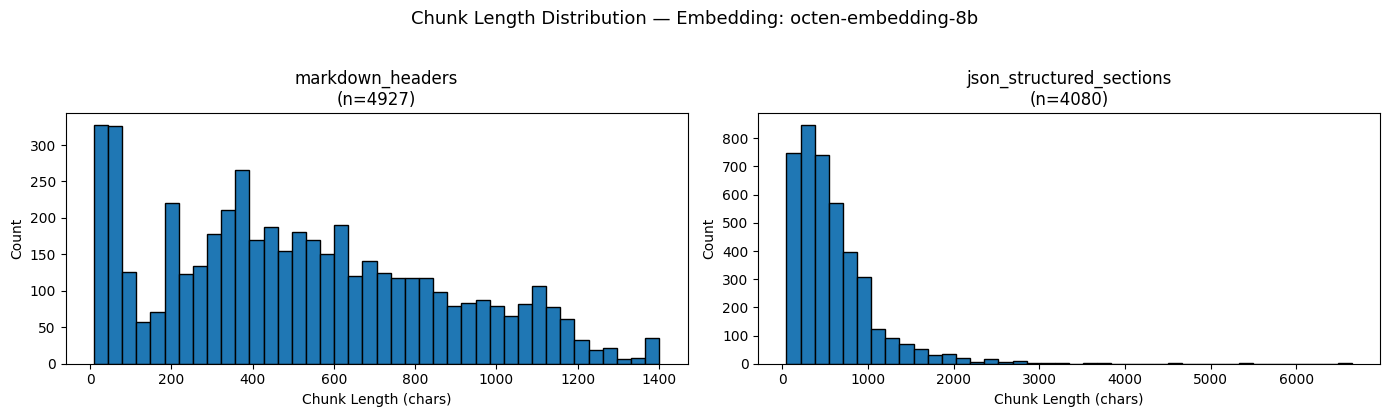

In [7]:
# Histogramme der Chunk-Längen für alle Methoden nebeneinander
fig, axes = plt.subplots(1, len(all_records), figsize=(7 * len(all_records), 4))
if len(all_records) == 1:
    axes = [axes]  # Sicherstellen, dass axes immer eine Liste ist

for ax, (method_name, records) in zip(axes, all_records.items()):
    lengths = [len(r['text']) for r in records]
    ax.hist(lengths, bins=40, edgecolor='black')
    ax.set_xlabel('Chunk Length (chars)')
    ax.set_ylabel('Count')
    ax.set_title(f'{method_name}\n(n={len(records)})')

fig.suptitle(f'Chunk Length Distribution — Embedding: {EMBED_SHORT}', fontsize=13, y=1.03)
plt.tight_layout()

# Figur speichern
fig_dir = FIGURES_DIR / '02_ingestion'
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / f'chunk_length_hist__{EMBED_SHORT}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Gespeichert: {fig_path}')

plt.show()

## 3) Embeddings erzeugen und in Qdrant hochladen

Für jede Chunking-Methode wird eine eigene Qdrant-Collection erstellt.
In `config.py` kann per `CHUNKING_MODE` umgeschaltet werden, welche Collection
die Evaluation-Notebooks (03–05) verwenden.

> **Laufzeit:** Embedding dauert ca. 4–6 Minuten pro Methode (~5000 Chunks).

In [8]:
def _truncate(text: str, max_chars: int = 500) -> str:
    """Truncate text to max_chars, breaking at the last space if possible.

    Args:
        text: Input text to truncate.
        max_chars: Maximum number of characters.

    Returns:
        Truncated text.
    """
    if len(text) <= max_chars:
        return text
    truncated = text[:max_chars]
    last_space = truncated.rfind(" ")
    if last_space > max_chars // 2:
        truncated = truncated[:last_space]
    return truncated


def embed_texts_litellm(texts: List[str], model: str = EMBED_MODEL_NAME, batch_size: int = EMBED_BATCH_SIZE, max_chars: int = EMBED_MAX_CHARS) -> List[List[float]]:
    """Embed a list of texts using the HPI API via LiteLLM.

    Args:
        texts: List of text strings to embed.
        model: Model identifier in LiteLLM format.
        batch_size: Number of texts to embed per API call.
        max_chars: Truncate texts to this many characters before embedding (None = no limit).

    Returns:
        List of embedding vectors (each a list of floats).
    """
    if max_chars:
        texts = [_truncate(t, max_chars) for t in texts]
    vectors = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]                # Aktuellen Batch aus der Textliste schneiden
        resp = embedding(model=model, input=batch, api_base=API_BASE_URL, encoding_format='float')
        for item in resp.data:
            vec = item.embedding if hasattr(item, 'embedding') else item.get('embedding')
            if vec is None:
                raise RuntimeError('Embedding response ohne Vektor erhalten.')
            vectors.append(vec)
        print(f'  Embedded {len(vectors)}/{len(texts)}', end='\r')  # Fortschrittsanzeige
    print()
    return vectors

In [9]:
# WARNING: Running this cell can take a couple of minutes (12) 

# Verbindung zu Qdrant herstellen
qdrant = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)
UPSERT_BATCH_SIZE = 64

# Für jede Chunking-Methode: Embeddings erzeugen, Collection erstellen, hochladen. 
# Bereits existierende Collections werden übersprungen (persistenter Docker-Storage).
for method_name, records in all_records.items():
    collection_name = f'grundschutz_chunks_{method_name}__{EMBED_SHORT}'  # Collection-Name aus Methode + Embedding ableiten

    # Prüfen, ob Collection bereits existiert — wenn ja, überspringen
    if LOAD_FROM_CACHE and qdrant.collection_exists(collection_name):
        info = qdrant.get_collection(collection_name)
        print(f'=== {method_name}: Collection existiert bereits ({info.points_count} Vektoren), übersprungen ===\n')
        continue

    texts = [r['text'] for r in records]  # Nur die Texte für das Embedding

    # Schritt 1: Embeddings erzeugen
    print(f'=== {method_name} ({len(texts)} Chunks) ===')
    print(f'Embedding...')
    vectors = embed_texts_litellm(texts)
    vector_size = len(vectors[0])

    # Schritt 2: Collection erstellen
    qdrant.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=vector_size, distance=Distance.COSINE),
    )

    # Schritt 3: Punkte erstellen — Chunk-Text und Metadaten im Payload
    points = [
        PointStruct(
            id=r['chunk_id'],
            vector=vectors[i],
            payload={
                'text': r['text'],
                'chunk_id': r['chunk_id'],
                **r['metadata'],           # Metadaten (page_numbers, citation_hint, etc.) einbetten
            },
        )
        for i, r in enumerate(records)
    ]

    # Schritt 4: Batch-Upload
    for batch_start in range(0, len(points), UPSERT_BATCH_SIZE):
        batch = points[batch_start:batch_start + UPSERT_BATCH_SIZE]
        qdrant.upsert(collection_name=collection_name, points=batch)
        print(f'  Uploaded {min(batch_start + UPSERT_BATCH_SIZE, len(points))}/{len(points)}', end='\r')

    info = qdrant.get_collection(collection_name)
    print(f'\nCollection "{collection_name}" ready: {info.points_count} Vektoren\n')

=== markdown_headers: Collection existiert bereits (4927 Vektoren), übersprungen ===

=== json_structured_sections: Collection existiert bereits (4080 Vektoren), übersprungen ===



## 4) Verifikation

Test-Suche auf allen Collections — gleiche Frage, verschiedene Chunking-Methoden.

In [10]:
# Test-Suche auf allen Collections mit der gleichen Frage
test_frage = 'Was ist der Unterschied zwischen Prozess- und Systembausteinen?'
test_vec = embed_texts_litellm([test_frage])[0]  # Frage in Vektor umwandeln

for method_name in all_records:
    collection_name = f'grundschutz_chunks_{method_name}__{EMBED_SHORT}'
    info = qdrant.get_collection(collection_name)

    response = qdrant.query_points(
        collection_name=collection_name,
        query=test_vec,
        limit=3,
        with_payload=True,
    )

    print(f'=== {method_name} ({info.points_count} Vektoren) ===')
    print(f'Frage: "{test_frage}"\n')
    for i, hit in enumerate(response.points):
        # Seitenzahlen anzeigen, falls vorhanden (nur bei json_structured_sections)
        pages = hit.payload.get('page_numbers', [])
        page_info = f' | Seiten: {pages}' if pages else ''
        print(f'  [{i+1}] Score: {hit.score:.4f}{page_info}')
        print(f'      {hit.payload["text"][:200]}...\n')
    print()

  Embedded 1/1
=== markdown_headers (4927 Vektoren) ===
Frage: "Was ist der Unterschied zwischen Prozess- und Systembausteinen?"

  [1] Score: 0.6790
      ## System-Bausteine:...

  [2] Score: 0.6042
      ## Prozess-Bausteine:

Die Prozess-Bausteine, die in der Regel für sämtliche oder große Teile eines Informationsverbunds gleichermaßen gelten, unterteilen sich in die folgenden Schichten, die wiederum...

  [3] Score: 0.5961
      ## Bausteine

Das IT-Grundschutz-Kompendium enthält für unterschiedliche Vorgehensweisen, Komponenten und IT-Systeme Erläuterungen zur Gefährdungslage, Sicherheitsanforderungen und weiterführende Info...


=== json_structured_sections (4080 Vektoren) ===
Frage: "Was ist der Unterschied zwischen Prozess- und Systembausteinen?"

  [1] Score: 0.6389 | Seiten: [25, 26]
      Prozess-Bausteine:

Die Prozess-Bausteine, die in der Regel für sämtliche oder große Teile eines Informationsverbunds gleichermaßen gelten, unterteilen sich in die folgenden Schichten, die

## Fertig

Für jede Chunking-Methode wurde eine eigene Qdrant-Collection erstellt.
Der Collection-Name enthält sowohl die Chunking-Methode als auch das Embedding-Modell:

`grundschutz_chunks_{chunking_mode}__{embedding_model}`

In `config.py` kann per `CHUNKING_MODE` und `EMBED_MODEL_NAME` umgeschaltet werden,
welche Collection die Notebooks 03–05 verwenden.

**Weiter geht es mit:**
- `w3_03_retrieval_evaluation.ipynb` — Retrieval-Metriken